In [1]:
from pathlib import Path
import numpy as np
import tifffile

images_dir = Path("../train_data/images")
masks_dir = Path("../train_data/masks")

image_paths = sorted(images_dir.glob("*.tiff"))
assert len(image_paths) > 0, "No image files found"

tile_size = 256
stride = 128
min_fg_pixels = 10   # skip empty mask tiles

def pad_minimum(img, mask, tile_size):
    h, w = img.shape
    pad_h = max(0, tile_size - h)
    pad_w = max(0, tile_size - w)

    if pad_h > 0 or pad_w > 0:
        img = np.pad(img, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=0)
        mask = np.pad(mask, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=0)

    return img, mask

X_tiles = []
y_tiles = []

for img_path in image_paths:
    mask_path = masks_dir / img_path.name
    if not mask_path.exists():
        print(f"Skipping {img_path.name}: no matching mask")
        continue

    img = np.asarray(tifffile.imread(str(img_path)))
    mask = np.asarray(tifffile.imread(str(mask_path)))

    if img.ndim == 3 and 1 in img.shape:
        img = np.squeeze(img)
    if mask.ndim == 3 and 1 in mask.shape:
        mask = np.squeeze(mask)

    if img.ndim != 2:
        raise ValueError(f"Expected 2D image for {img_path.name}, got shape {img.shape}")
    if mask.ndim != 2:
        raise ValueError(f"Expected 2D mask for {mask_path.name}, got shape {mask.shape}")
    if img.shape != mask.shape:
        raise ValueError(f"Shape mismatch for {img_path.name}: image {img.shape}, mask {mask.shape}")

    img, mask = pad_minimum(img, mask, tile_size)

    h, w = img.shape

    # sliding-window tiles
    for y0 in range(0, h - tile_size + 1, stride):
        for x0 in range(0, w - tile_size + 1, stride):
            img_tile = img[y0:y0+tile_size, x0:x0+tile_size]
            mask_tile = mask[y0:y0+tile_size, x0:x0+tile_size]

            # skip mostly empty tiles
            if np.count_nonzero(mask_tile) < min_fg_pixels:
                continue

            X_tiles.append(img_tile[..., None])   # (256, 256, 1)
            y_tiles.append(mask_tile[..., None])  # (256, 256, 1)

X = np.stack(X_tiles, axis=0).astype(np.float32)
y = np.stack(y_tiles, axis=0).astype(np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("num tiles:", len(X_tiles))
print("unique labels in first mask tile:", np.unique(y[0])[:20])

X shape: (33, 256, 256, 1)
y shape: (33, 256, 256, 1)
num tiles: 33
unique labels in first mask tile: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [2]:
# use all images in all splits, since that is what you wanted earlier
np.savez("train.npz", X=X, y=y)
np.savez("val.npz", X=X, y=y)
np.savez("test.npz", X=X, y=y)

print("Wrote train.npz, val.npz, test.npz")

Wrote train.npz, val.npz, test.npz


In [3]:
import os
import tempfile
import tensorflow as tf
import matplotlib.pyplot as plt

from deepcell.image_generators import CroppingDataGenerator
from deepcell.losses import weighted_categorical_crossentropy
from deepcell.model_zoo.panopticnet import PanopticNet
from deepcell.utils.train_utils import count_gpus, rate_scheduler
from deepcell_toolbox.processing import histogram_normalization

In [4]:
# load the npz files, same style as the DeepCell notebook
with np.load("train.npz") as data:
    X_train = data["X"]
    y_train = data["y"]

with np.load("val.npz") as data:
    X_val = data["X"]
    y_val = data["y"]

with np.load("test.npz") as data:
    X_test = data["X"]
    y_test = data["y"]

print(X_train.shape, y_train.shape)

(33, 256, 256, 1) (33, 256, 256, 1)


In [5]:
# training parameters based on the DeepCell notebook
backbone = "efficientnetv2bl"
location = True
pyramid_levels = ["P1", "P2", "P3", "P4", "P5", "P6", "P7"]

seed = 0
min_objects = 1
zoom_min = 0.75
crop_size = 256

outer_erosion_width = 1
inner_distance_alpha = "auto"
inner_distance_beta = 1
inner_erosion_width = 0

epochs = 16
batch_size = 4
lr = 1e-4

model_path = "NuclearSegmentation.keras"
train_log = "train_log.csv"

In [6]:
import numpy as np

def augment_90_flip(X, y):
    X_aug = []
    y_aug = []

    for x, m in zip(X, y):
        for k in range(4):  # 0, 90, 180, 270
            xr = np.rot90(x, k=k, axes=(0, 1))
            mr = np.rot90(m, k=k, axes=(0, 1))

            X_aug.append(xr)
            y_aug.append(mr)

            X_aug.append(np.flip(xr, axis=0))  # vertical flip
            y_aug.append(np.flip(mr, axis=0))

            X_aug.append(np.flip(xr, axis=1))  # horizontal flip
            y_aug.append(np.flip(mr, axis=1))

    return (
        np.stack(X_aug, axis=0).astype(np.float32),
        np.stack(y_aug, axis=0).astype(np.int32),
    )

X_train = histogram_normalization(X_train)
X_val = histogram_normalization(X_val)

X_train_aug, y_train_aug = augment_90_flip(X_train, y_train)

datagen = CroppingDataGenerator(
    rotation_range=0,
    zoom_range=(1.0, 1.0),
    horizontal_flip=False,
    vertical_flip=False,
    crop_size=(crop_size, crop_size),
    fill_mode="constant",
    cval=0,
)

datagen_val = CroppingDataGenerator(
    rotation_range=0,
    zoom_range=(1.0, 1.0),
    horizontal_flip=False,
    vertical_flip=False,
    crop_size=(crop_size, crop_size),
    fill_mode="constant",
    cval=0,
)

transforms = ["inner-distance", "outer-distance", "fgbg"]

transforms_kwargs = {
    "outer-distance": {"erosion_width": outer_erosion_width},
    "inner-distance": {
        "alpha": inner_distance_alpha,
        "beta": inner_distance_beta,
        "erosion_width": inner_erosion_width,
    },
}

train_data = datagen.flow(
    {"X": X_train_aug, "y": y_train_aug},
    seed=seed,
    min_objects=min_objects,
    transforms=transforms,
    transforms_kwargs=transforms_kwargs,
    batch_size=batch_size,
)

val_data = datagen_val.flow(
    {"X": X_val, "y": y_val},
    seed=seed,
    min_objects=min_objects,
    transforms=transforms,
    transforms_kwargs=transforms_kwargs,
    batch_size=batch_size,
)

print("X_train_aug:", X_train_aug.shape)
print("y_train_aug:", y_train_aug.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train_aug: (396, 256, 256, 1)
y_train_aug: (396, 256, 256, 1)
X_val: (33, 256, 256, 1)
y_val: (33, 256, 256, 1)


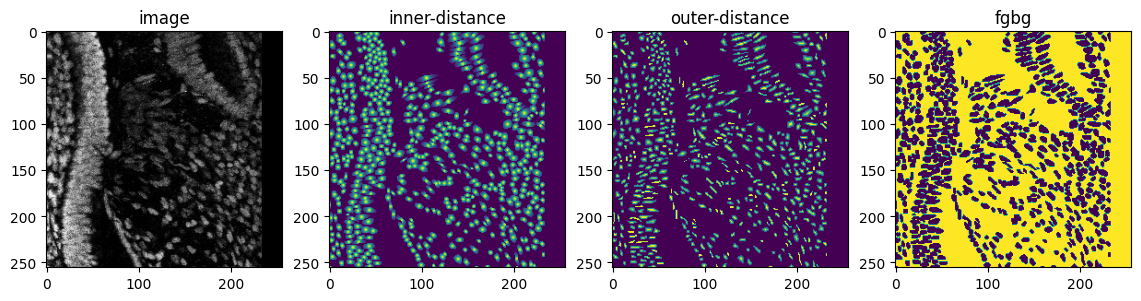

In [7]:
# optional sanity check
inputs, outputs = train_data.next()

img = inputs[0]
inner_distance = outputs[0]
outer_distance = outputs[1]
fgbg = outputs[2]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img[..., 0], cmap="gray")
axes[0].set_title("image")
axes[1].imshow(inner_distance[0, ..., 0], cmap="viridis")
axes[1].set_title("inner-distance")
axes[2].imshow(outer_distance[0, ..., 0], cmap="viridis")
axes[2].set_title("outer-distance")
axes[3].imshow(fgbg[0, ..., 0], cmap="viridis")
axes[3].set_title("fgbg")
plt.show()

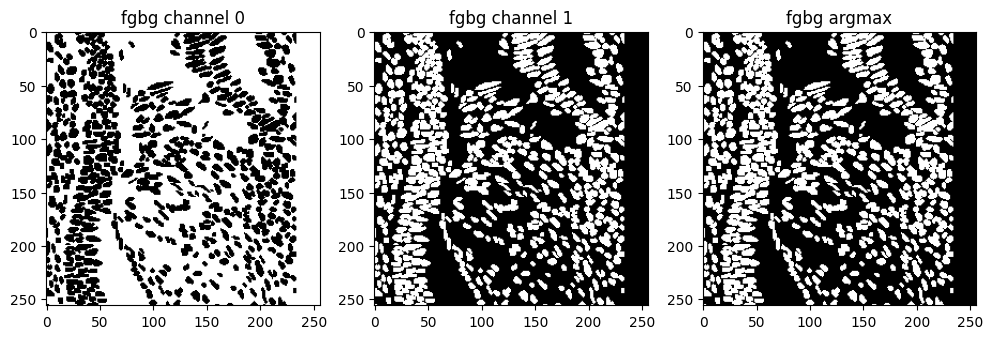

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(fgbg[0, ..., 0], cmap="gray")
axes[0].set_title("fgbg channel 0")

axes[1].imshow(fgbg[0, ..., 1], cmap="gray")
axes[1].set_title("fgbg channel 1")

axes[2].imshow(np.argmax(fgbg[0], axis=-1), cmap="gray")
axes[2].set_title("fgbg argmax")

plt.show()

In [9]:
# build model
input_shape = (crop_size, crop_size, 1)

model = PanopticNet(
    backbone=backbone,
    input_shape=input_shape,
    norm_method=None,
    num_semantic_classes=[1, 1, 2],
    location=location,
    include_top=True,
    backbone_levels=["C1", "C2", "C3", "C4", "C5"],
    pyramid_levels=pyramid_levels,
)

2026-05-12 12:02:31.491883: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 12:02:33.132540: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38279 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:ed:00.0, compute capability: 8.0


473186304/473176280 [==============================] - 11s 0us/step


In [10]:
# losses + compile
def semantic_loss(n_classes):
    def _semantic_loss(y_true, y_pred):
        if n_classes > 1:
            return 0.01 * weighted_categorical_crossentropy(
                y_true, y_pred, n_classes=n_classes
            )
        return tf.keras.losses.MSE(y_true, y_pred)
    return _semantic_loss

loss = {}
for layer in model.layers:
    if layer.name.startswith("semantic_"):
        n_classes = layer.output_shape[-1]
        loss[layer.name] = semantic_loss(n_classes)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=0.001)
model.compile(loss=loss, optimizer=optimizer)

print(model.input_shape)

(None, 256, 256, 1)


In [11]:
# train
tf.keras.backend.clear_session()

monitor = "val_loss"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        model_path,
        monitor=monitor,
        save_best_only=True,
        verbose=1,
        save_weights_only=False,
    ),
    tf.keras.callbacks.LearningRateScheduler(rate_scheduler(lr=lr, decay=0.99)),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor,
        factor=0.1,
        patience=5,
        verbose=1,
        min_delta=0.0001,
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.CSVLogger(train_log),
]

print(f"Training on {count_gpus()} GPUs.")

history = model.fit(
    train_data,
    steps_per_epoch=max(1, train_data.y.shape[0] // batch_size),
    epochs=epochs,
    validation_data=val_data,
    validation_steps=max(1, val_data.y.shape[0] // batch_size),
    callbacks=callbacks,
)

print("Final val_loss:", history.history["val_loss"][-1])

2026-05-12 12:03:15.545452: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /device:GPU:0 with 38279 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:ed:00.0, compute capability: 8.0


Training on 1 GPUs.
Epoch 1/16


2026-05-12 12:04:16.978269: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8800


99/99 [==============================] - ETA: 0s - loss: 0.0951 - semantic_0_loss: 0.0435 - semantic_1_loss: 0.0477 - semantic_2_loss: 0.0038
Epoch 1: val_loss improved from inf to 0.08978, saving model to NuclearSegmentation.keras
99/99 [==============================] - 129s 654ms/step - loss: 0.0951 - semantic_0_loss: 0.0435 - semantic_1_loss: 0.0477 - semantic_2_loss: 0.0038 - val_loss: 0.0898 - val_semantic_0_loss: 0.0519 - val_semantic_1_loss: 0.0347 - val_semantic_2_loss: 0.0031 - lr: 1.0000e-04
Epoch 2/16
99/99 [==============================] - ETA: 0s - loss: 0.0585 - semantic_0_loss: 0.0255 - semantic_1_loss: 0.0303 - semantic_2_loss: 0.0027
Epoch 2: val_loss improved from 0.08978 to 0.05762, saving model to NuclearSegmentation.keras
99/99 [==============================] - 61s 609ms/step - loss: 0.0585 - semantic_0_loss: 0.0255 - semantic_1_loss: 0.0303 - semantic_2_loss: 0.0027 - val_loss: 0.0576 - val_semantic_0_loss: 0.0251 - val_semantic_1_loss: 0.0300 - val_semantic_2_

In [12]:
# save a lighter prediction model, same pattern as the DeepCell notebook
with tempfile.TemporaryDirectory() as tmpdirname:
    weights_path = os.path.join(tmpdirname, "model_weights.h5")
    model.save_weights(weights_path, save_format="h5")

    prediction_model = PanopticNet(
        backbone=backbone,
        input_shape=input_shape,
        norm_method=None,
        num_semantic_heads=2,
        num_semantic_classes=[1, 1],
        location=location,
        include_top=True,
        backbone_levels=["C1", "C2", "C3", "C4", "C5"],
        pyramid_levels=pyramid_levels,
    )
    prediction_model.load_weights(weights_path, by_name=True)

prediction_model.save("NuclearSegmentation_prediction.keras")
print("Saved prediction model")

Saved prediction model
